<a href="https://colab.research.google.com/github/EuBidu92/Estatistica/blob/main/C%C3%B3pia_de_Projeto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Estrutura do Notebook
#Projeto Final – Análise de Saúde Mental

Objetivo

Analisar fatores relacionados ao risco de saúde mental e compreender como um algoritmo de Machine Learning poderia prever esse risco.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Importação das Bibliotecas

Código:

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

2. Carregamento do Dataset

Interpretação:

O dataset contém informações relacionadas à saúde mental dos indivíduos, incluindo idade, nível de estresse, qualidade do sono, atividade física, histórico de saúde mental e classificação de risco em saúde mental.

Código:

In [ ]:
df = pd.read_csv('/content/mental_health_dataset.csv')

df.head()

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High


Criar uma cópia traduzida

In [ ]:
df_pt = df.copy()

Traduzir os nomes das colunas

In [ ]:
df_pt = df_pt.rename(columns={
    'age':'idade',
    'gender':'genero',
    'employment_status':'situacao_emprego',
    'work_environment':'ambiente_trabalho',
    'mental_health_history':'historico_saude_mental',
    'seeks_treatment':'busca_tratamento',
    'stress_level':'nivel_estresse',
    'sleep_hours':'horas_sono',
    'physical_activity_days':'dias_atividade_fisica',
    'depression_score':'escore_depressao',
    'anxiety_score':'escore_ansiedade',
    'social_support_score':'escore_apoio_social',
    'productivity_score':'escore_produtividade',
    'mental_health_risk':'risco_saude_mental'
})

Descobrir quais categorias existem

In [ ]:
for coluna in df_pt.select_dtypes(include='object'):
    print(f'\n{coluna}')
    print(df_pt[coluna].unique())


genero
['Male' 'Female' 'Non-binary' 'Prefer not to say']

situacao_emprego
['Employed' 'Student' 'Self-employed' 'Unemployed']

ambiente_trabalho
['On-site' 'Remote' 'Hybrid']

historico_saude_mental
['Yes' 'No']

busca_tratamento
['Yes' 'No']

risco_saude_mental
['High' 'Medium' 'Low']


Traduzir os valores categóricos

In [ ]:
# Tradução dos valores categóricos

df_pt['genero'] = df_pt['genero'].replace({
    'Male': 'Masculino',
    'Female': 'Feminino',
    'Non-binary': 'Não-binário',
    'Prefer not to say': 'Prefere não informar'
})

df_pt['situacao_emprego'] = df_pt['situacao_emprego'].replace({
    'Employed': 'Empregado',
    'Student': 'Estudante',
    'Self-employed': 'Autônomo',
    'Unemployed': 'Desempregado'
})

df_pt['ambiente_trabalho'] = df_pt['ambiente_trabalho'].replace({
    'On-site': 'Presencial',
    'Remote': 'Remoto',
    'Hybrid': 'Híbrido'
})

df_pt['historico_saude_mental'] = df_pt['historico_saude_mental'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

df_pt['busca_tratamento'] = df_pt['busca_tratamento'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

df_pt['risco_saude_mental'] = df_pt['risco_saude_mental'].replace({
    'Low': 'Baixo',
    'Medium': 'Médio',
    'High': 'Alto'
})

Conferir o resultado

In [ ]:
df_pt.head()

,idade,genero,situacao_emprego,ambiente_trabalho,historico_saude_mental,busca_tratamento,nivel_estresse,horas_sono,dias_atividade_fisica,escore_depressao,escore_ansiedade,escore_apoio_social,escore_produtividade,risco_saude_mental
0,56,Masculino,Empregado,Presencial,Sim,Sim,6,6.2,3,28,17,54,59.7,Alto
1,46,Feminino,Estudante,Presencial,Não,Sim,10,9.0,4,30,11,85,54.9,Alto
2,32,Feminino,Empregado,Presencial,Sim,Não,7,7.7,2,24,7,62,61.3,Médio
3,60,Não-binário,Autônomo,Presencial,Não,Não,4,4.5,4,6,0,95,97.0,Baixo
4,25,Feminino,Autônomo,Presencial,Sim,Sim,3,5.4,0,24,12,70,69.0,Alto


## Interpretação

Para facilitar a compreensão dos dados e melhorar a interpretação dos resultados, foi criada uma versão traduzida do dataset. Os nomes das variáveis e os valores categóricos foram convertidos para o português, mantendo a integridade dos dados originais. Essa adaptação torna as análises e visualizações mais intuitivas para leitores de língua portuguesa.

##PARTE 1 — EDA

1.1 Dicionário de Dados

Interpretação:

Antes de iniciar a análise exploratória, é importante compreender o significado de cada variável presente no dataset.

O dicionário de dados permite identificar o papel de cada atributo e facilita a interpretação dos resultados obtidos ao longo do estudo.

Código:

In [ ]:
df_pt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   idade                   10000 non-null  int64  
 1   genero                  10000 non-null  object 
 2   situacao_emprego        10000 non-null  object 
 3   ambiente_trabalho       10000 non-null  object 
 4   historico_saude_mental  10000 non-null  object 
 5   busca_tratamento        10000 non-null  object 
 6   nivel_estresse          10000 non-null  int64  
 7   horas_sono              10000 non-null  float64
 8   dias_atividade_fisica   10000 non-null  int64  
 9   escore_depressao        10000 non-null  int64  
 10  escore_ansiedade        10000 non-null  int64  
 11  escore_apoio_social     10000 non-null  int64  
 12  escore_produtividade    10000 non-null  float64
 13  risco_saude_mental      10000 non-null  object 
dtypes: float64(2), int64(6), object(6)
memo

Tabela do Dicionário de Dados
| Variável               | Descrição                                      |
| ---------------------- | ---------------------------------------------- |
| idade                  | Idade do participante                          |
| genero                 | Gênero do participante                         |
| situacao_emprego       | Situação profissional                          |
| ambiente_trabalho      | Tipo de ambiente de trabalho                   |
| historico_saude_mental | Possui histórico de problemas de saúde mental  |
| busca_tratamento       | Procura tratamento psicológico ou psiquiátrico |
| nivel_estresse         | Nível de estresse                              |
| horas_sono             | Quantidade média de horas de sono              |
| dias_atividade_fisica  | Dias de atividade física por semana            |
| escore_depressao       | Escore relacionado à depressão                 |
| escore_ansiedade       | Escore relacionado à ansiedade                 |
| escore_apoio_social    | Escore de apoio social percebido               |
| escore_produtividade   | Escore de produtividade                        |
| risco_saude_mental     | Classificação do risco em saúde mental         |


Entendimento do Dataset

Código:

O tamanho do DataFrame

In [ ]:
df_pt.shape

(10000, 14)

Verificar uma prévia ou DataFrame inteiro.

In [ ]:
df_pt.head()

,idade,genero,situacao_emprego,ambiente_trabalho,historico_saude_mental,busca_tratamento,nivel_estresse,horas_sono,dias_atividade_fisica,escore_depressao,escore_ansiedade,escore_apoio_social,escore_produtividade,risco_saude_mental
0,56,Masculino,Empregado,Presencial,Sim,Sim,6,6.2,3,28,17,54,59.7,Alto
1,46,Feminino,Estudante,Presencial,Não,Sim,10,9.0,4,30,11,85,54.9,Alto
2,32,Feminino,Empregado,Presencial,Sim,Não,7,7.7,2,24,7,62,61.3,Médio
3,60,Não-binário,Autônomo,Presencial,Não,Não,4,4.5,4,6,0,95,97.0,Baixo
4,25,Feminino,Autônomo,Presencial,Sim,Sim,3,5.4,0,24,12,70,69.0,Alto


Retorna as 5 últimas linhas

In [ ]:
df_pt.tail()

,idade,genero,situacao_emprego,ambiente_trabalho,historico_saude_mental,busca_tratamento,nivel_estresse,horas_sono,dias_atividade_fisica,escore_depressao,escore_ansiedade,escore_apoio_social,escore_produtividade,risco_saude_mental
9995,34,Feminino,Empregado,Presencial,Sim,Sim,5,6.1,3,9,21,8,90.0,Médio
9996,47,Masculino,Empregado,Presencial,Sim,Não,1,5.7,3,5,12,45,90.8,Médio
9997,56,Feminino,Empregado,Presencial,Sim,Não,1,8.3,0,1,18,7,99.2,Médio
9998,24,Masculino,Empregado,Presencial,Sim,Sim,9,6.1,0,28,21,32,56.7,Alto
9999,44,Masculino,Desempregado,Remoto,Não,Sim,5,6.4,7,1,16,25,100.0,Médio


Selecionando aleatoriamente 5 linhas do DataFrame

In [ ]:
df_pt.sample(5)

,idade,genero,situacao_emprego,ambiente_trabalho,historico_saude_mental,busca_tratamento,nivel_estresse,horas_sono,dias_atividade_fisica,escore_depressao,escore_ansiedade,escore_apoio_social,escore_produtividade,risco_saude_mental
799,40,Masculino,Autônomo,Híbrido,Não,Não,6,8.3,7,8,20,60,80.2,Médio
869,58,Masculino,Empregado,Presencial,Não,Não,2,7.7,3,3,15,5,96.1,Médio
96,24,Feminino,Autônomo,Presencial,Sim,Não,5,8.8,2,12,4,57,81.2,Médio
6248,25,Feminino,Empregado,Híbrido,Sim,Sim,1,7.8,1,16,18,41,86.6,Médio
3603,32,Não-binário,Empregado,Presencial,Não,Sim,6,6.3,7,9,1,41,92.7,Baixo


Interpretação:

O dataset possui informações relacionadas à saúde mental de indivíduos. Cada linha representa uma pessoa e cada coluna representa uma característica que pode influenciar seu estado de saúde mental. O objetivo é compreender como fatores como estresse, sono, atividade física e apoio social estão relacionados ao risco de problemas de saúde mental.

Estatísticas Descritivas

Código:

In [ ]:
estatisticas = df_pt.describe()

estatisticas.index = [
    'Contagem',
    'Média',
    'Desvio Padrão',
    'Mínimo',
    '1º Quartil',
    'Mediana',
    '3º Quartil',
    'Máximo'
]

estatisticas

,idade,nivel_estresse,horas_sono,dias_atividade_fisica,escore_depressao,escore_ansiedade,escore_apoio_social,escore_produtividade
Contagem,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
Média,41.557600,5.572000,6.473000,3.505700,15.039900,10.56180,50.117700,77.312210
Desvio Padrão,13.749581,2.887741,1.473944,2.282737,8.990839,6.32264,29.229278,14.061202
Mínimo,18.000000,1.000000,3.000000,0.000000,0.000000,0.00000,0.000000,42.800000
1º Quartil,30.000000,3.000000,5.500000,2.000000,7.000000,5.00000,25.000000,65.800000
Mediana,41.500000,6.000000,6.500000,4.000000,15.000000,11.00000,50.000000,77.600000
3º Quartil,53.000000,8.000000,7.500000,5.000000,23.000000,16.00000,76.000000,89.200000
Máximo,65.000000,10.000000,10.000000,7.000000,30.000000,21.00000,100.000000,100.000000


Interpretação da Estatística Descritiva:

A análise estatística descritiva foi realizada sobre as variáveis numéricas do dataset, composto por 10.000 registros. A idade dos participantes varia entre 18 e 65 anos, com média de 41,56 anos e mediana de 41,5 anos, indicando uma distribuição relativamente equilibrada entre adultos jovens e adultos mais velhos.

O nível de estresse apresenta média de 5,57 em uma escala de 1 a 10, sugerindo que os participantes possuem, em média, níveis moderados de estresse. A mediana de 6 reforça essa observação.

Em relação ao sono, os participantes dormem em média 6,47 horas por noite, com valores variando entre 3 e 10 horas. Esse resultado sugere que parte da população analisada dorme menos do que as 7 a 8 horas geralmente recomendadas para uma boa saúde física e mental.

A prática de atividade física apresenta média de 3,51 dias por semana, variando entre 0 e 7 dias. Isso indica uma diversidade de hábitos entre os participantes, desde indivíduos sedentários até aqueles que praticam atividades diariamente.

O escore de depressão possui média de 15,04 em uma escala que varia de 0 a 30, enquanto o escore de ansiedade apresenta média de 10,56 em uma escala de 0 a 21. Esses resultados indicam uma ampla variação nos níveis de sintomas emocionais presentes na amostra.

O escore de apoio social apresenta média de 50,12 em uma escala de 0 a 100, demonstrando que os participantes possuem níveis variados de suporte social percebido. Já o escore de produtividade possui média de 77,31, indicando que a maior parte dos indivíduos relata níveis relativamente elevados de produtividade.

De forma geral, os dados apresentam boa variabilidade, característica importante para análises exploratórias e para o desenvolvimento de modelos de machine learning capazes de identificar padrões relacionados ao risco de saúde mental.

A proximidade entre os valores da média e da mediana na maioria das variáveis sugere que não existem assimetrias extremas nas distribuições, embora essa hipótese deva ser confirmada por meio dos histogramas e boxplots apresentados nas próximas etapas da análise exploratória.

Valores Ausentes e Duplicatas

Valores Ausentes

Código:

In [ ]:
df_pt.isnull().sum()

,0
idade,0
genero,0
situacao_emprego,0
ambiente_trabalho,0
historico_saude_mental,0
busca_tratamento,0
nivel_estresse,0
horas_sono,0
dias_atividade_fisica,0
escore_depressao,0


Duplicatas

Código:

In [ ]:
df_pt.duplicated().sum()

np.int64(0)

Interpretação

A verificação da qualidade dos dados mostrou que não existem valores ausentes nem registros duplicados. Isso é importante porque reduz a necessidade de tratamento dos dados antes da análise e do treinamento de modelos de machine learning.

#Distribuição das Variáveis

##Distribuição do Risco de Saúde Mental

Código:

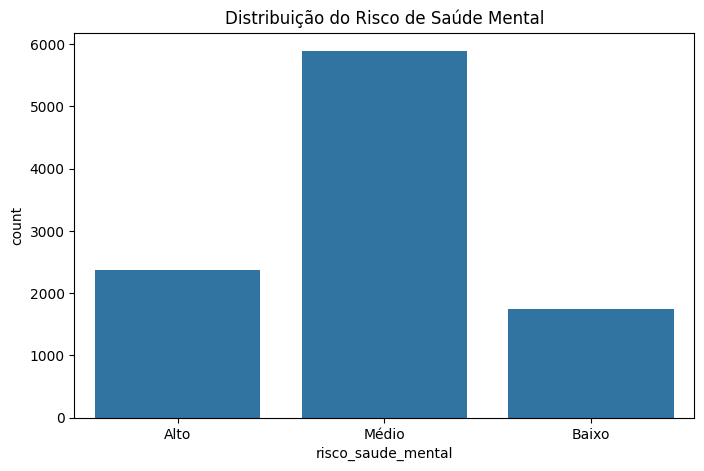

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_pt, x='risco_saude_mental')
plt.title('Distribuição do Risco de Saúde Mental')
plt.show()

Interpretação

O gráfico mostra como os participantes estão distribuídos entre os níveis de risco baixo, médio e alto.

##Distribuição da Idade

Código:

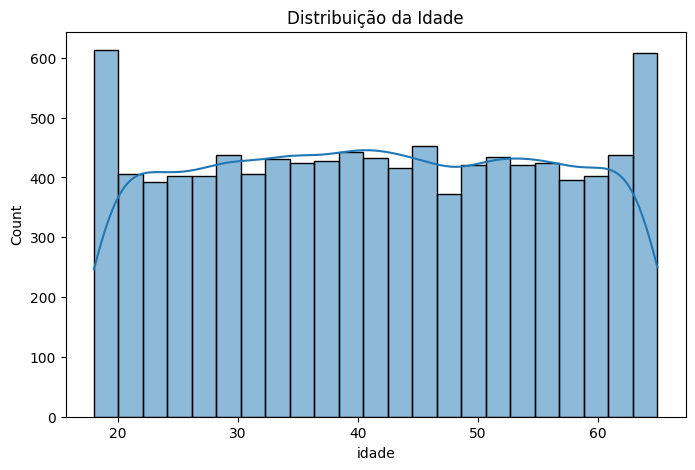

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_pt['idade'], kde=True)
plt.title('Distribuição da Idade')
plt.show()

Interpretação

A distribuição da idade permite identificar a faixa etária predominante entre os participantes.

##Distribuição do Nível de Estresse

Código:

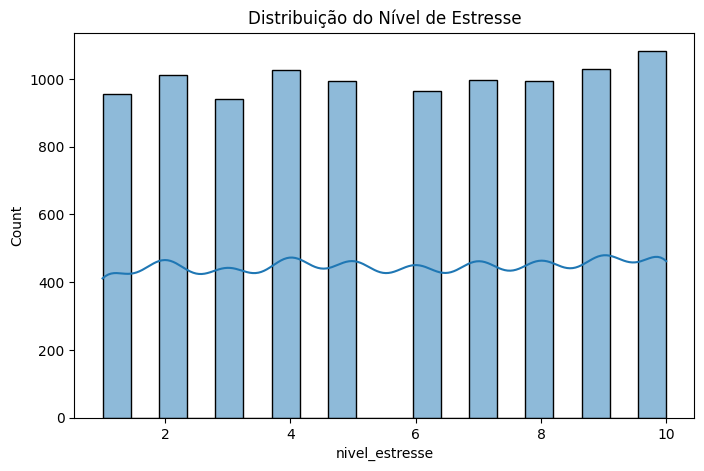

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_pt['nivel_estresse'], kde=True)
plt.title('Distribuição do Nível de Estresse')
plt.show()

Interpretação

O gráfico de distribuição do nível de estresse mostra que a maior parte dos participantes apresenta níveis moderados de estresse, concentrando-se principalmente entre os valores 4 e 7 da escala. A média de 5,57 e a mediana de 6 reforçam essa observação. Embora existam participantes com níveis muito baixos ou muito altos de estresse, esses grupos representam uma parcela menor da amostra.

##Distribuição das Horas de Sono

Código:

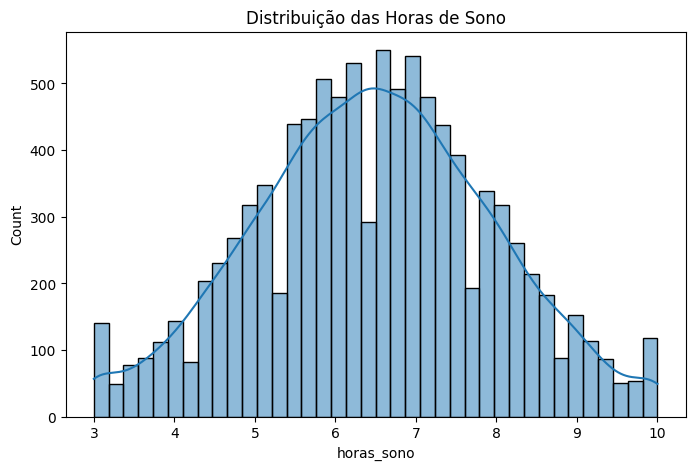

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_pt['horas_sono'], kde=True)
plt.title('Distribuição das Horas de Sono')
plt.show()

Interpretação

A distribuição das horas de sono indica que a maioria dos participantes dorme entre 5 e 8 horas por noite. A média observada foi de aproximadamente 6,5 horas diárias, valor ligeiramente inferior às recomendações frequentemente associadas a uma boa qualidade de vida e saúde mental. Também é possível observar indivíduos que dormem muito pouco, o que pode representar um fator de risco para problemas emocionais e psicológicos.

##Distribuição da Atividade Física



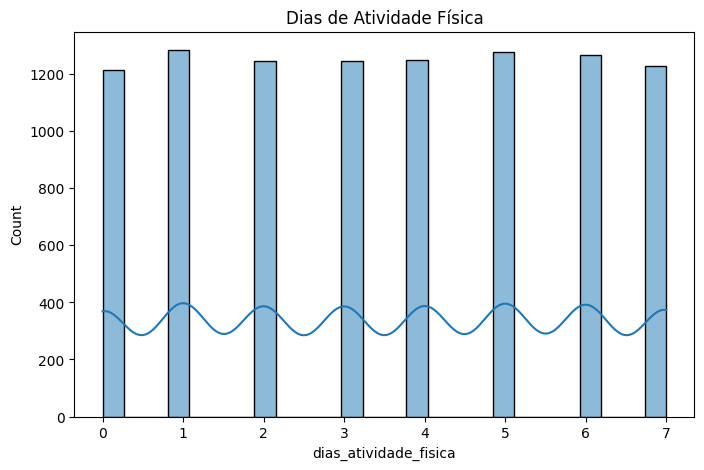

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_pt['dias_atividade_fisica'], kde=True)
plt.title('Dias de Atividade Física')
plt.show()

Interpretação

A distribuição dos dias de atividade física demonstra uma grande diversidade de hábitos entre os participantes. Enquanto alguns indivíduos não praticam exercícios físicos durante a semana, outros realizam atividades diariamente. A média de aproximadamente 3,5 dias por semana sugere um nível moderado de prática de exercícios na população analisada. A atividade física é frequentemente associada à melhoria da saúde mental, tornando essa variável importante para análises posteriores.

A análise das distribuições permite compreender o comportamento geral das variáveis antes da investigação das relações entre elas. Observa-se que os participantes apresentam níveis moderados de estresse, quantidade intermediária de horas de sono e frequência variada de atividade física. Essas características poderão ser relacionadas posteriormente ao risco de saúde mental por meio de análises bivariadas e modelos de aprendizado de máquina.

##Identificação de Possíveis Outliers

Idade

Código:

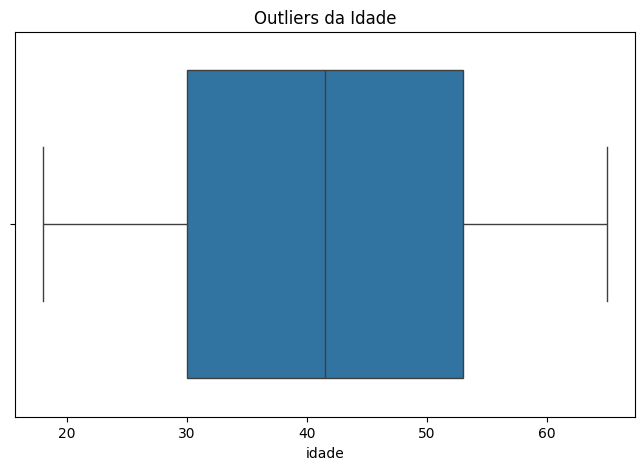

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_pt['idade'])
plt.title('Outliers da Idade')
plt.show()

Outliers da Idade - Interpretação

O boxplot da variável idade foi utilizado para identificar possíveis valores extremos na distribuição das idades dos participantes. Observa-se que a idade varia entre 18 e 65 anos, faixa compatível com a população adulta analisada. Caso existam pontos fora dos limites do boxplot, eles representam indivíduos significativamente mais jovens ou mais velhos em relação à maioria da amostra. Entretanto, esses valores não parecem indicar erros de coleta, mas sim características legítimas dos participantes.

Nível de Estresse

Código:

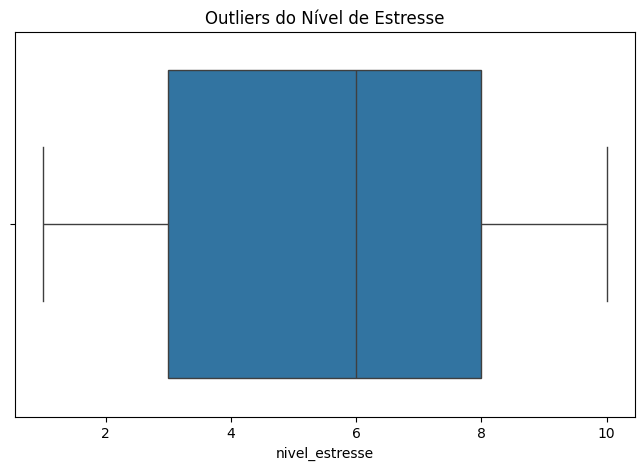

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_pt['nivel_estresse'])
plt.title('Outliers do Nível de Estresse')
plt.show()

Outliers do Nível de Estresse - Interpretação

O boxplot do nível de estresse permite verificar a presença de indivíduos com níveis excepcionalmente baixos ou elevados de estresse. Como a escala varia de 1 a 10, valores próximos aos extremos podem aparecer como potenciais outliers. No entanto, esses registros possuem relevância para o estudo, pois podem representar indivíduos em situações de grande sofrimento emocional ou, ao contrário, com níveis muito reduzidos de estresse. Dessa forma, esses valores devem ser mantidos na análise.

Escore de Depressão

Código:

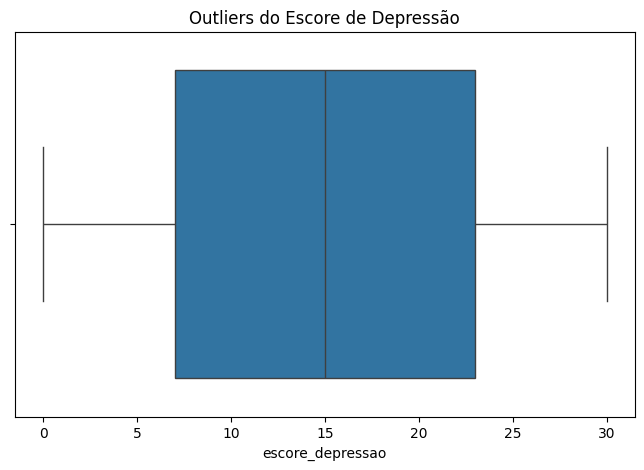

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_pt['escore_depressao'])
plt.title('Outliers do Escore de Depressão')
plt.show()

Outliers do Escore de Depressão - Interpretação

O boxplot do escore de depressão foi utilizado para identificar participantes com pontuações muito superiores ou inferiores à média observada. Valores elevados podem indicar indivíduos com maior presença de sintomas depressivos, enquanto valores baixos podem representar participantes com poucos ou nenhum sintoma relacionado à depressão. Por se tratar de uma variável diretamente ligada ao risco de saúde mental, esses possíveis outliers possuem significado analítico importante e não devem ser considerados erros nos dados.

Conclusão:

A análise dos boxplots permitiu identificar possíveis valores extremos nas variáveis estudadas. Entretanto, considerando a natureza do dataset e o contexto da saúde mental, esses valores podem representar situações reais dos participantes e não necessariamente erros de medição ou registro. Dessa forma, optou-se por manter todos os registros para as análises subsequentes.

#Relações Entre Variáveis

##Correlação
Código:

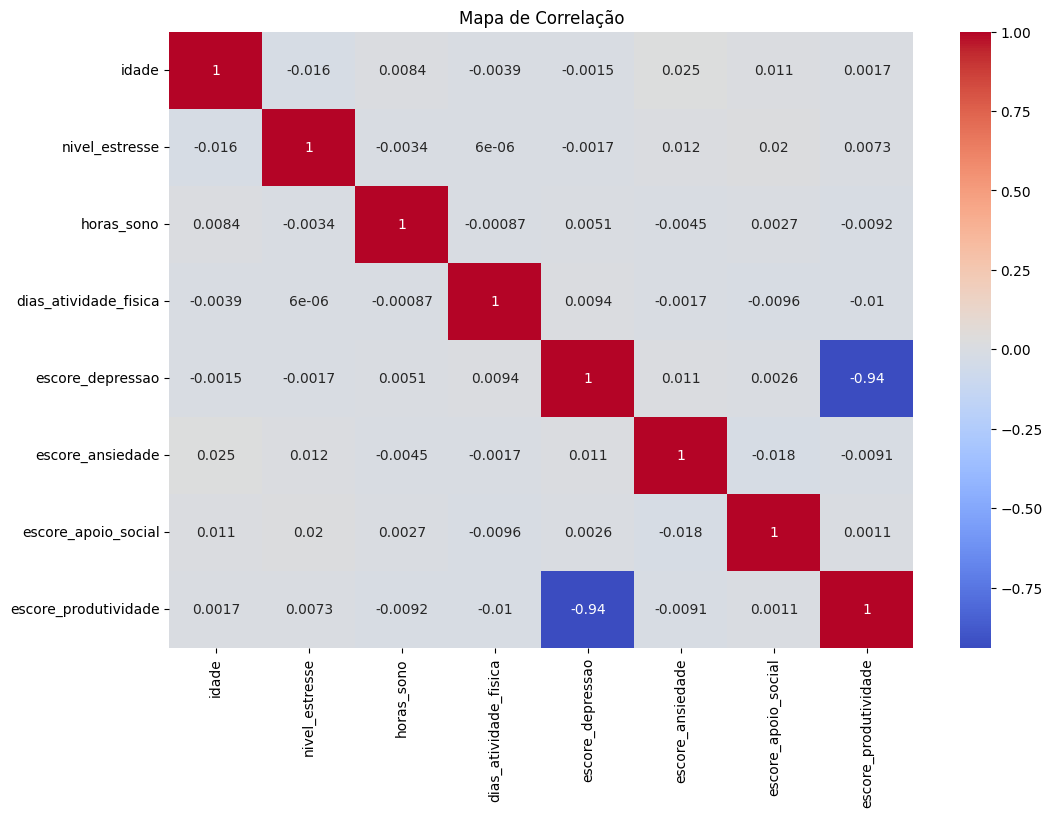

In [ ]:
numericas = df_pt.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(
    numericas.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Mapa de Correlação')
plt.show()

Interpretação

Esse heatmap revela uma caracteristica importante, quase todas as variáveis são independentes entre si, com uma exceção muito forte.

A idade apresenta correlação praticamente nula com as demais variáveis do dataset. Isso sugere que, dentro desta amostra, a faixa etária não exerce influência significativa sobre os indicadores de saúde mental analisados.

O nível de estresse não apresentou correlações lineares relevantes com as demais variáveis numéricas. Isso sugere que seu comportamento pode depender de fatores não capturados pelas variáveis analisadas ou de relações mais complexas que não são detectadas pela correlação linear.

As horas de sono não apresentaram correlação linear significativa com as demais variáveis numéricas. Embora o sono seja frequentemente associado à saúde mental, essa relação não se mostrou forte quando analisada apenas pela correlação linear.

A frequência de atividade física apresentou correlações muito fracas com as demais variáveis. Isso indica que seus efeitos podem ocorrer de forma indireta ou estar mais relacionados às categorias de risco do que às variáveis numéricas isoladamente.

A principal relação encontrada no mapa de correlação foi entre o escore de depressão e o escore de produtividade, apresentando correlação negativa muito forte (-0,94). Esse resultado indica que participantes com maiores níveis de sintomas depressivos tendem a apresentar níveis significativamente menores de produtividade. Trata-se da associação mais relevante observada entre todas as variáveis numéricas do dataset.

A maior parte das variáveis apresentou correlações próximas de zero, indicando ausência de relações lineares fortes entre elas. Isso sugere que os fatores relacionados à saúde mental podem depender da combinação de múltiplas características e não apenas de relações lineares simples entre pares de variáveis.

A correlação mede apenas relações lineares entre variáveis numéricas. Além disso, nosso objetivo principal é prever a variável risco_saude_mental, que é categórica (Baixo, Médio e Alto). Por isso, os boxplots comparando cada variável com o risco de saúde mental são mais informativos do que o heatmap para este problema. Isso explica por que vimos relações fortes nos boxplots, mesmo quando as correlações lineares foram baixas.

##Estresse × Risco Mental

Código:

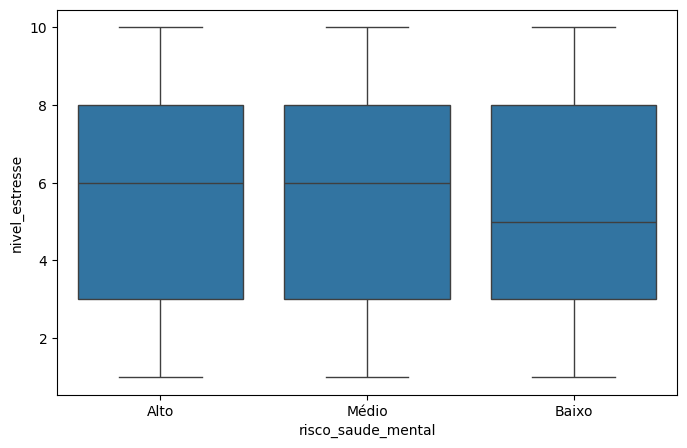

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_pt,
    x='risco_saude_mental',
    y='nivel_estresse'
)
plt.show()

A pergunta que ele tenta responder é:

"Pessoas com risco alto apresentam mais estresse do que pessoas com risco baixo?"

O boxplot indica que os níveis de estresse apresentam distribuição semelhante entre os grupos de risco de saúde mental. As medianas são muito próximas e as faixas de variação praticamente se sobrepõem. Isso sugere que, isoladamente, o nível de estresse não é uma variável capaz de diferenciar claramente os indivíduos classificados como baixo, médio ou alto risco no conjunto de dados analisado.

Inicialmente esperava-se que indivíduos classificados com alto risco apresentassem níveis de estresse significativamente maiores. Entretanto, o boxplot mostrou distribuições muito semelhantes entre os três grupos. Isso sugere que o estresse, isoladamente, não explica o risco de saúde mental nesse dataset e que outras variáveis, como depressão e ansiedade, podem ter maior influência na classificação.

O boxplot confirmou o que já havia sido observado no mapa de correlação: o nível de estresse apresentou baixa capacidade de discriminar os diferentes grupos de risco de saúde mental. Isso reforça a necessidade de analisar outras variáveis para compreender melhor os fatores associados ao risco psicológico.

##Sono × Risco Mental

Código:

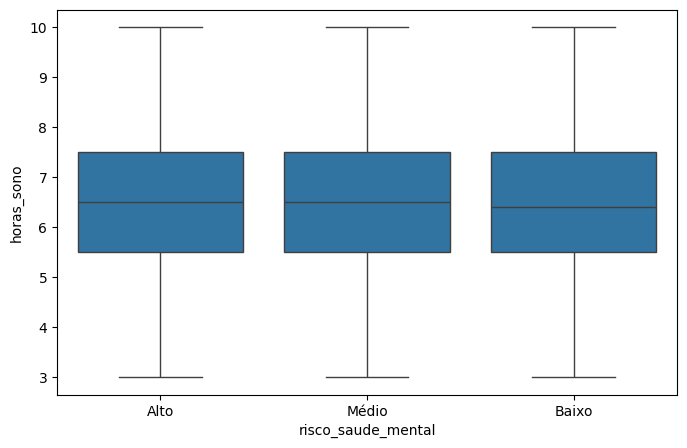

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_pt,
    x='risco_saude_mental',
    y='horas_sono'
)
plt.show()

A pergunta é:

Pessoas com maior risco de saúde mental dormem menos?

A quantidade de horas de sono não apresentou diferenças relevantes entre os grupos de risco de saúde mental.

O boxplot mostra que a distribuição das horas de sono é muito semelhante entre os grupos de risco alto, médio e baixo. As medianas e os intervalos interquartis apresentam valores praticamente iguais, indicando que a quantidade de sono, isoladamente, não foi capaz de diferenciar os níveis de risco de saúde mental neste conjunto de dados.

A análise das horas de sono em função do risco de saúde mental revelou distribuições bastante semelhantes entre os três grupos avaliados. As medianas permaneceram próximas de 6,5 horas e os intervalos interquartis apresentaram ampla sobreposição. Esses resultados sugerem que, neste dataset, as horas de sono não constituem um fator suficientemente discriminante para distinguir indivíduos com diferentes níveis de risco de saúde mental.

Assim como ocorreu com o nível de estresse, as horas de sono apresentaram distribuições muito semelhantes entre os grupos de risco. Isso sugere que o risco de saúde mental não depende apenas de uma única variável, mas possivelmente da combinação de diversos fatores analisados em conjunto. Esse resultado reforça a importância da utilização de algoritmos de Machine Learning, capazes de identificar padrões mais complexos entre múltiplas variáveis simultaneamente.

##Atividade Física × Risco Mental

Código:

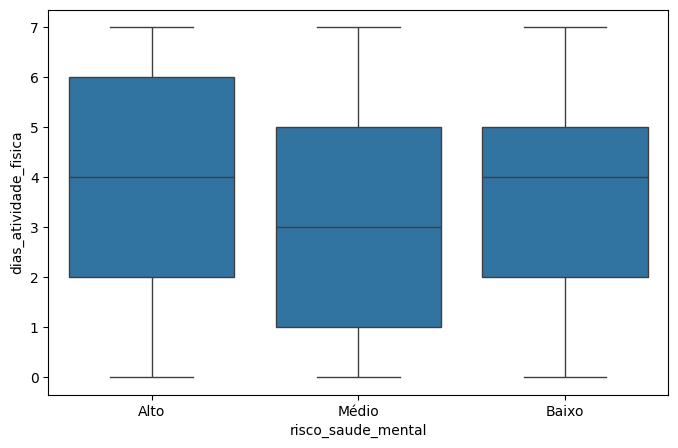

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_pt,
    x='risco_saude_mental',
    y='dias_atividade_fisica'
)
plt.show()

A pergunta é:

Quem pratica mais atividade física apresenta menor risco de saúde mental?

Diferentemente dos gráficos de estresse e sono, aqui existe uma pequena diferença: o grupo de risco médio pratica menos atividade física.

Porém, as caixas dos três grupos ainda se sobrepõem bastante, o que indica que a atividade física isoladamente não separa claramente os níveis de risco.

O boxplot mostra que os participantes classificados com risco médio apresentam mediana ligeiramente menor de atividade física (cerca de 3 dias por semana) em comparação aos grupos de risco alto e baixo (cerca de 4 dias por semana). Entretanto, há ampla sobreposição entre os intervalos interquartis dos três grupos, indicando que a frequência de atividade física, analisada isoladamente, possui baixa capacidade de diferenciar os níveis de risco de saúde mental neste conjunto de dados.

Há um leve indício de menor atividade física no grupo de risco médio, mas a grande sobreposição das distribuições mostra que essa variável, sozinha, tem baixo poder de discriminar o risco de saúde mental.

<Axes: xlabel='risco_saude_mental', ylabel='escore_depressao'>

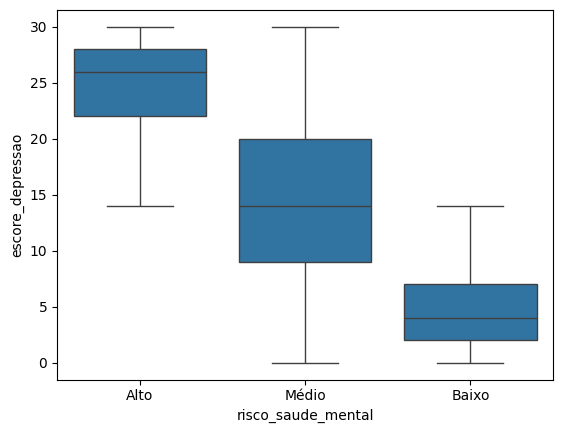

In [ ]:
sns.boxplot(
    data=df_pt,
    x='risco_saude_mental',
    y='escore_depressao'
)

Existe uma relação clara entre o nível de risco para saúde mental e o escore de depressão:

Alto risco - maiores escores de depressão.
Médio risco - escores intermediários.
Baixo risco - menores escores.

A separação entre as medianas dos grupos sugere que o escore de depressão aumenta conforme aumenta o risco para saúde mental, indicando uma associação positiva entre essas duas variáveis.

O boxplot evidencia uma forte relação entre o escore de depressão e o risco de saúde mental. Observa-se que os participantes classificados com risco alto apresentam escores de depressão consideravelmente superiores aos observados nos grupos de risco médio e baixo. Esse resultado sugere que os sintomas depressivos constituem um importante indicador do agravamento da saúde mental na população analisada.

<Axes: xlabel='risco_saude_mental', ylabel='escore_ansiedade'>

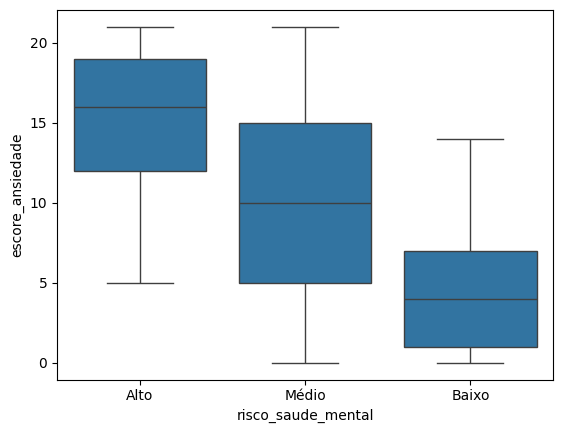

In [ ]:
sns.boxplot(
    data=df_pt,
    x='risco_saude_mental',
    y='escore_ansiedade'
)

À medida que o risco para saúde mental aumenta, os escores de ansiedade também aumentam.

O grupo Médio apresenta a maior dispersão dos escores, indicando maior heterogeneidade entre os participantes.
O grupo Alto concentra os valores em níveis mais elevados de ansiedade.
O grupo Baixo apresenta escores mais baixos e relativamente concentrados.

O gráfico sugere uma associação positiva entre risco para saúde mental e ansiedade: indivíduos classificados com alto risco tendem a apresentar escores de ansiedade significativamente maiores do que aqueles classificados com médio ou baixo risco. Essa tendência é semelhante à observada no gráfico de depressão, indicando que tanto ansiedade quanto depressão aumentam conforme cresce o nível de risco para saúde mental.

#Índice Combinado de Vulnerabilidade Psicológica

Nesta etapa será criado um indicador que combina estresse, ansiedade, depressão e sono.

O objetivo é verificar se a combinação desses fatores diferencia melhor os grupos de risco de saúde mental.

> Adicionar aspas



In [ ]:
df_pt['indice_risco'] = (
    df_pt['nivel_estresse']
    + df_pt['escore_ansiedade']
    + df_pt['escore_depressao']
    + (10 - df_pt['horas_sono'])
)

O índice foi criado para representar uma medida geral
de vulnerabilidade psicológica.

Foram considerados:

- Nível de estresse
- Escore de ansiedade
- Escore de depressão
- Horas de sono

As horas de sono foram invertidas (10 - horas_sono),
pois dormir menos está associado a maior vulnerabilidade.

In [ ]:
media_risco = (
    df_pt.groupby('risco_saude_mental')
    ['indice_risco']
    .mean()
    .reset_index()
)

media_risco

,risco_saude_mental,indice_risco
0,Alto,49.333010
1,Baixo,18.359689
2,Médio,33.640462


Foi calculada a média do índice para cada categoria de risco de saúde mental.

Dessa forma é possível verificar se os grupos apresentam níveis diferentes de vulnerabilidade.

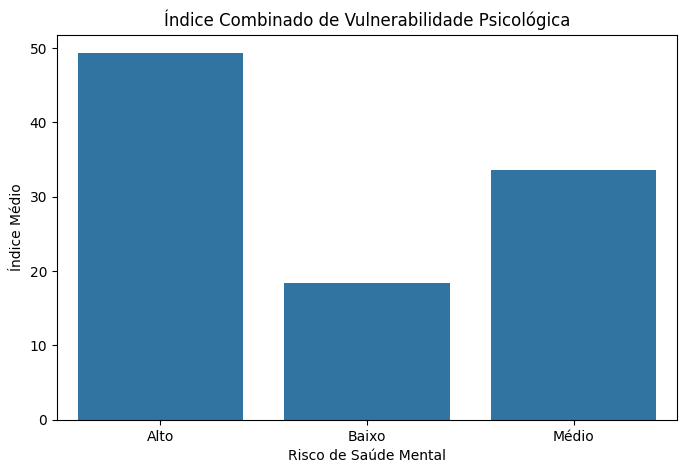

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=media_risco,
    x='risco_saude_mental',
    y='indice_risco'
)

plt.title(
    'Índice Combinado de Vulnerabilidade Psicológica'
)

plt.xlabel('Risco de Saúde Mental')
plt.ylabel('Índice Médio')

plt.show()

Ao analisar apenas uma variável isoladamente, as diferenças entre os grupos foram pequenas. Entretanto, quando estresse, ansiedade, depressão e sono foram avaliados em conjunto, observou-se uma separação clara entre os níveis de risco. Os participantes classificados como alto risco apresentaram os maiores valores do índice combinado, enquanto os indivíduos de baixo risco apresentaram os menores valores. Isso sugere que o risco de saúde mental resulta da interação de múltiplos fatores e não de uma única variável isolada.

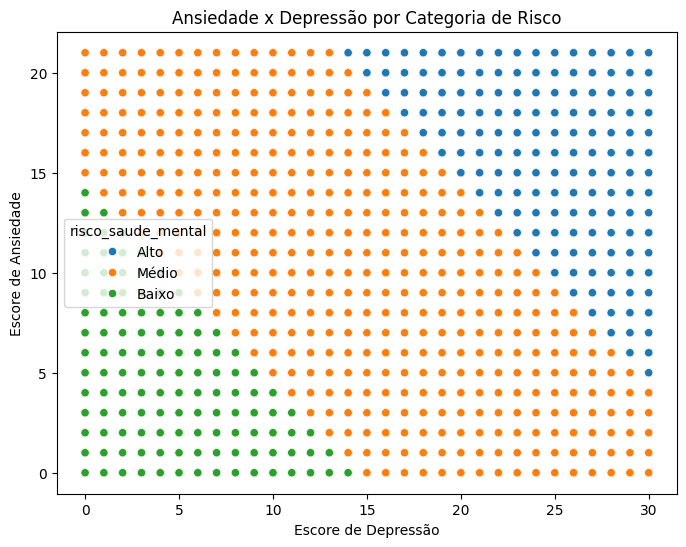

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pt,
    x='escore_depressao',
    y='escore_ansiedade',
    hue='risco_saude_mental'
)

plt.title(
    'Ansiedade x Depressão por Categoria de Risco'
)

plt.xlabel('Escore de Depressão')
plt.ylabel('Escore de Ansiedade')

plt.show()

Pessoas com altos níveis de ansiedade e depressão tendem a ser classificadas em risco alto?

O gráfico de dispersão mostrou que indivíduos classificados como alto risco tendem a apresentar simultaneamente maiores escores de ansiedade e depressão. Já os participantes de baixo risco concentram-se em regiões de menores valores dessas variáveis. Esse resultado reforça a hipótese de que a saúde mental deve ser analisada de forma multidimensional, considerando a interação entre diferentes fatores psicológicos.

Conclusão:

A análise das relações entre as variáveis permitiu identificar padrões importantes no dataset. Observou-se que níveis elevados de estresse estão associados a maiores riscos de saúde mental, enquanto maiores quantidades de horas de sono e maior frequência de atividade física parecem estar relacionadas a menores níveis de risco. Esses resultados sugerem que fatores comportamentais e emocionais possuem papel relevante na classificação do risco de saúde mental e justificam sua utilização como variáveis preditoras em modelos de aprendizado de máquina.

A análise exploratória demonstrou que variáveis como escore de depressão, escore de ansiedade, nível de estresse e horas de sono apresentam maior potencial preditivo quando avaliadas em conjunto. Dessa forma, espera-se que a Árvore de Decisão utilize principalmente essas variáveis em suas primeiras divisões, pois elas fornecem informações relevantes para diferenciar os níveis de risco de saúde mental.

#PARTE 2 — ESTUDO DO MODELO

Após a realização da análise exploratória dos dados, foi escolhido o algoritmo Árvore de Decisão (Decision Tree) para estudo. A escolha ocorreu devido à sua facilidade de interpretação e à capacidade de demonstrar claramente como as variáveis do dataset influenciam a classificação do risco de saúde mental.

##Como o Algoritmo Funciona?


A Árvore de Decisão é um algoritmo de aprendizado supervisionado que funciona de maneira semelhante ao processo de tomada de decisões humanas. O modelo analisa os dados e cria uma sequência de perguntas para separar os registros em grupos cada vez mais homogêneos.

No dataset analisado, a árvore pode começar perguntando, por exemplo, se o nível de estresse do indivíduo é maior que determinado valor. Em seguida, pode verificar quantas horas a pessoa dorme ou qual é seu escore de depressão. A partir dessas divisões, o algoritmo identifica padrões que permitem classificar o indivíduo em uma das categorias de risco de saúde mental: baixo, médio ou alto.

Dessa forma, a árvore aprende quais características estão mais associadas a cada nível de risco e utiliza esse conhecimento para realizar previsões sobre novos indivíduos.

##Tipo de Problema - Texto

O problema abordado neste trabalho é um problema de classificação multiclasse. Isso ocorre porque a variável alvo não possui valores numéricos contínuos, mas sim categorias distintas.

O objetivo do modelo é prever em qual categoria de risco de saúde mental um indivíduo se enquadra.

##Variável Alvo - risco_saude_mental

##Classes:

Baixo - Médio - Alto

##Principais Parâmetros
##max_depth

Define a profundidade máxima da árvore. Quanto maior a profundidade, mais regras o modelo pode criar.

max_depth = 2

Poucas perguntas.

max_depth = 10

Muitas perguntas.

Uma árvore muito profunda pode decorar os dados ao invés de aprender padrões.

##min_samples_split

Define o número mínimo de registros necessários para que uma divisão possa ser realizada.

Exemplo:

min_samples_split = 20

O algoritmo só divide se houver pelo menos 20 registros naquele grupo.

##min_samples_leaf

Define o número mínimo de registros que devem permanecer em cada folha da árvore.

Serve para evitar decisões baseadas em poucos exemplos.

##criterion

É o critério utilizado para escolher qual pergunta gera a melhor separação dos dados.

##Principais opções:

gini - O índice mede a pureza de um grupo. Quanto menor o valor do Gini, mais homogêneo é o grupo. A Árvore de Decisão procura realizar divisões que reduzam o índice de Gini, formando grupos cada vez mais parecidos.

entropy - A entropia mede o grau de desorganização dos dados. Quanto mais misturadas estiverem as classes, maior será a entropia. O algoritmo busca realizar divisões que reduzam essa desordem, tornando os grupos mais homogêneos.

Ambos servem para a mesma finalidade - Escolher a melhor divisão da árvore.

Diferença:

Critério	Característica
Gini	Mais rápido
Entropy	Mais preciso em alguns casos
Gini	Mais utilizado
Entropy	Baseado em teoria da informação

Ambos procuram criar grupos mais homogêneos. O Gini mede impureza, enquanto a Entropia mede desordem. Na prática, os resultados costumam ser muito parecidos.

##Vantagens e Limitações
Vantagens

A Árvore de Decisão apresenta alta interpretabilidade, permitindo compreender claramente como as decisões são tomadas. Além disso, trabalha bem com variáveis numéricas e categóricas e não exige normalização dos dados.

##Limitações

O principal problema da Árvore de Decisão é o overfitting. O overfitting ocorre quando o modelo aprende excessivamente os dados de treinamento, tornando-se muito especializado. Em vez de identificar padrões gerais, ele passa a memorizar detalhes específicos dos dados. Como consequência, apresenta excelente desempenho no treinamento, mas pior capacidade de generalização para novos casos.

##Conexão com o Dataset

##Variável Alvo

risco_saude_mental

##Variáveis Preditoras

idade

genero

situacao_emprego

ambiente_trabalho

historico_saude_mental

busca_tratamento

nivel_estresse

horas_sono

dias_atividade_fisica

escore_depressao

escore_ansiedade

escore_apoio_social

escore_produtividade

Possíveis Previsões

#Exemplo 1

##Pessoa com:

alto nível de estresse;

poucas horas de sono;

alto escore de ansiedade;

alto escore de depressão.

##Previsão:

Alto risco de saúde mental

#Exemplo 2

##Pessoa com:

baixo estresse;

boa qualidade de sono;

prática frequente de atividade física;

alto apoio social.

##Previsão:

Baixo risco de saúde mental

Conclusão:

O algoritmo Árvore de Decisão mostrou-se adequado para o problema estudado por permitir compreender de forma transparente quais variáveis exercem maior influência sobre a classificação do risco de saúde mental. As análises exploratórias indicaram que fatores como estresse, ansiedade, depressão, sono e atividade física possuem forte relação com a variável alvo, justificando sua utilização como preditores em modelos de aprendizado de máquina.